# Demo: A Purcell-filtered readout line

This demo is a **case study**, not a tutorial: it assembles the concepts from
Tutorials 1 (fitting a LOM), 3 (resonator chains), and 6 (readout parameters)
into the readout circuit most superconducting-qubit chips actually use:

```
[P1: drive line] -- C_d -- QUBIT -- Cc_qr -- READOUT -- Cc_rf -- FILTER -- Cc_out -- [P2: feedline]
```

* the **qubit** is a lumped LC tank,
* the **readout resonator** and the **Purcell filter** are $\lambda/2$ CPW
  lines of the same length, so the filter sits on resonance with the readout,
* the filter is strongly tapped onto the 50 $\Omega$ feedline (large
  $C_{c,\mathrm{out}}$), which makes it a broad bandpass around the readout
  frequency.

The filter's job: let readout photons out **fast** at $f_r$ while blocking the
qubit's spontaneous emission at $f_q$, a couple of GHz below. We compute

1. the circuit schematic and the feedline-band transmission,
2. the **environment admittance** $Y(\omega)$ the qubit sees, and from it the
   Purcell limit $T_1(\omega) = C_q / \mathrm{Re}\,Y(\omega)$,
3. the protection the filter buys at **matched readout linewidth** $\kappa_r$
   (the fair comparison),
4. the same curves with the two CPWs replaced by their fitted **Optimized
   LOMs** — the distributed-to-lumped reduction this package is about,
5. a design sweep of the filter–feedline coupling.

> **Scope of the model.** The qubit here is a *linear* LC: frequencies,
> couplings, $\kappa$, and the electromagnetic (Purcell) $T_1$ limit are all
> linear-network quantities and carry over to a transmon at leading order.
> Anything that needs anharmonicity — dispersive shift $\chi$, photon-number
> effects, measurement-induced dephasing — is outside what a linear model can
> give, so it is deliberately absent here. $\Gamma_1 = \mathrm{Re}\,Y(\omega_q)/C_q$
> is the standard linear-response emission rate into a shunting admittance
> (Esteve *et al.* 1986; Houck *et al.* 2008).

In [2]:
import time
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf
from scipy.signal import find_peaks

from simpleLOMs import (
    CPWParams, fit_lom, invert_monotonic,
    resonator_chain_network_2port,
    plot_transmission, plot_curves,
    apply_style, axis_label,
    MODEL_COLORS, COLOR_PRIMARY, COLOR_SECONDARY, COLOR_HIGHLIGHT,
)
from simpleLOMs.schematics import resonator_chain_schematic_2port

apply_style()

cpw = CPWParams(ep_r=11.45)        # ultracold-silicon chip, as in the tutorials
Z0 = 50.0
Y0 = 1.0 / Z0

# Qubit: a linear LC stand-in for a transmon
f_q = 5.2e9                        # design qubit frequency (Hz)
C_q = 65e-15                       # qubit shunt capacitance
L_q = 1.0 / ((2 * np.pi * f_q) ** 2 * C_q)

# Readout resonator and Purcell filter: same-length lambda/2 CPWs, ~7.3 GHz
d_r = 8.1e-3                       # readout length (m)
d_f = 8.1e-3                       # filter length (m) -> on-resonance filter

Cc_qr  = 4e-15                     # qubit <-> readout coupler
Cc_rf  = 2e-15                     # readout <-> filter coupler
Cc_out = 120e-15                   # filter <-> feedline coupler (sets kappa_f)
C_d    = 0.05e-15                  # weak drive-line tap on the qubit
Ctog   = 1e-14                     # ground caps flanking each CPW segment

print(f"qubit LC: L_q = {L_q*1e9:.3f} nH, C_q = {C_q*1e15:.0f} fF "
      f"-> f_q = {1/(2*np.pi*np.sqrt(L_q*C_q))/1e9:.3f} GHz")

qubit LC: L_q = 14.412 nH, C_q = 65 fF -> f_q = 5.200 GHz


## 1. The device as a chain

The whole circuit is one `resonator_chain_network_2port` call with a
**mixed** segment list — a lumped LC (the qubit) followed by two CPW lines.
Port 1 is the qubit's weakly tapped drive line, port 2 is the feedline. The
lumped qubit carries no ground caps (its $C_q$ already is the node
capacitance), so its two `Ctogs` entries are 0.

In [3]:
seg_qubit = {"kind": "lc", "L": L_q, "C": C_q}
segments_full = [seg_qubit, {"kind": "cpw", "d": d_r}, {"kind": "cpw", "d": d_f}]
Ccs_full = [C_d, Cc_qr, Cc_rf, Cc_out]
Ctogs_full = [0, 0, Ctog, Ctog, Ctog, Ctog]

figdir = Path("figures")
figdir.mkdir(exist_ok=True)

schematic = resonator_chain_schematic_2port(
    segments_full, Ccs_full, Ctogs_full,
    cpw_params=cpw, freq=rf.Frequency(6e9, 8e9, 3, unit="Hz"), Z0=Z0,
    annotations={
        "P1": "qubit drive line",
        "P2": "readout feedline",
        "roles": "qubit | readout | Purcell filter",
    },
)
schematic.save_svg(figdir / "purcell_chain.svg")
schematic.save_html(figdir / "purcell_chain.html")
schematic

Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.chain.resonator_chain_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'res1', 'label': 'resonator 1'}, {'id': 'res2', 'label': 'resonator 2'}, {'id': 'res3', 'label': 'resonator 3'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='Cc1', type='cap', label='C_{c1}', value='0.05 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 5e-17}), Component(id='LC1', type='lc', label='LC 1', value='L = 14.41 nH\nC = 65.00 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'L': 1.4411866130282459e-08, 'C': 6.5e-14}), Component(id='Cc2', type='cap', label='C_{c2}', value='4.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 4e-15}), Component(id='Ctog3', type='cap', label='C_{tog3}', value='10.00 fF', ports=['a', 'gnd'], group='res2', orient='shunt', props={'C': 1e-14}), Component(id='TL2', type='tline', label='CPW 2', value='\\ell = 8.10 mm', ports=['in', 'out'], group='res2', orient='series', props={'length': 0.0081, 'Z0': 46.426279628091585}), Component(id='Ctog4', type='cap', label='C_{tog4}', value='10.00 fF', ports=['a', 'gnd'], group='res2', orient='shunt', props={'C': 1e-14}), Component(id='Cc3', type='cap', label='C_{c3}', value='2.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 2e-15}), Component(id='Ctog5', type='cap', label='C_{tog5}', value='10.00 fF', ports=['a', 'gnd'], group='res3', orient='shunt', props={'C': 1e-14}), Component(id='TL3', type='tline', label='CPW 3', value='\\ell = 8.10 mm', ports=['in', 'out'], group='res3', orient='series', props={'length': 0.0081, 'Z0': 46.426279628091585}), Component(id='Ctog6', type='cap', label='C_{tog6}', value='10.00 fF', ports=['a', 'gnd'], group='res3', orient='shunt', props={'C': 1e-14}), Component(id='Cc4', type='cap', label='C_{c4}', value='120.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 1.2e-13}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'LC1.a']), Net(id='n3', ports=['LC1.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'Cc2.a']), Net(id='n5', ports=['Cc2.b', 'Ctog3.a']), Net(id='n6', ports=['Ctog3.gnd', 'GND']), Net(id='n7', ports=['Cc2.b', 'TL2.in']), Net(id='n8', ports=['TL2.out', 'Ctog4.a']), Net(id='n9', ports=['Ctog4.gnd', 'GND']), Net(id='n10', ports=['TL2.out', 'Cc3.a']), Net(id='n11', ports=['Cc3.b', 'Ctog5.a']), Net(id='n12', ports=['Ctog5.gnd', 'GND']), Net(id='n13', ports=['Cc3.b', 'TL3.in']), Net(id='n14', ports=['TL3.out', 'Ctog6.a']), Net(id='n15', ports=['Ctog6.gnd', 'GND']), Net(id='n16', ports=['TL3.out', 'Cc4.a']), Net(id='n17', ports=['Cc4.b', 'P2.in'])], annotations={'P1': 'qubit drive line', 'P2': 'readout feedline', 'roles': 'qubit | readout | Purcell filter'})

Transmission from the drive line to the feedline in the readout band shows
the filter as a broad pass-band with the much narrower readout line inside
it. (The qubit's own peak at 5.2 GHz is there too, but its Purcell-limited
linewidth is well below any sensible broadband grid spacing — a needle this
plot cannot resolve — so we restrict the plot to the readout band.)

[12.4 s] full-chain band build


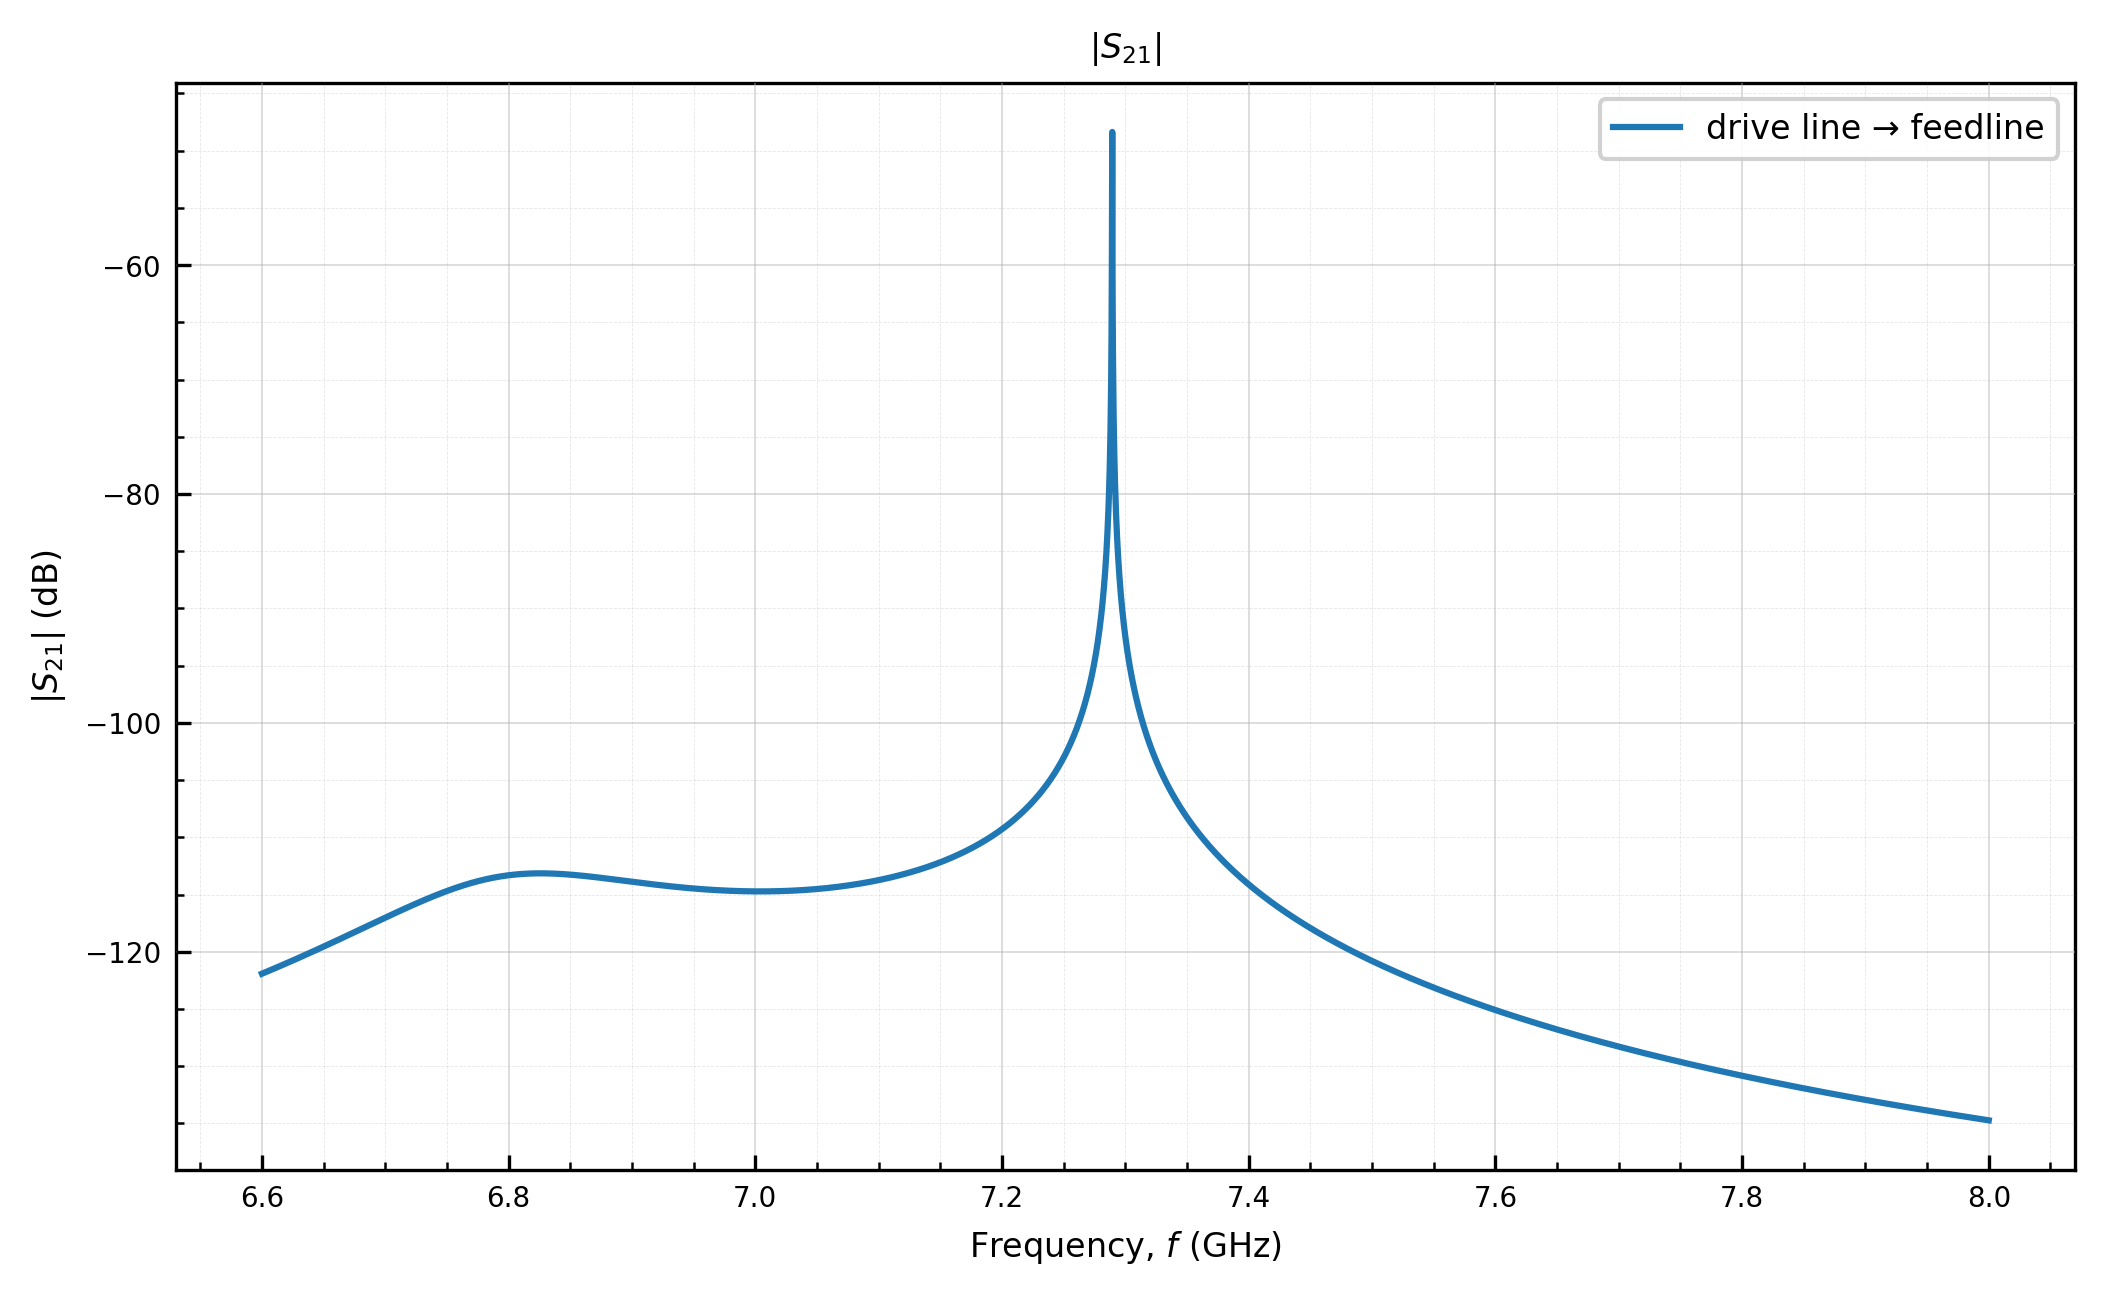

(<Figure size 2117.1x1308.44 with 1 Axes>,
 <Axes: title={'center': '$|S_{21}|$'}, xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>)

In [4]:
t0 = time.time()
freq_band = rf.Frequency(6.6e9, 8.0e9, 5_001, unit="Hz")
full_cpw = resonator_chain_network_2port(
    freq_band, segments_full, Ccs_full, Ctogs_full, cpw_params=cpw, Z0=Z0,
)
print(f"[{time.time()-t0:.1f} s] full-chain band build")

plot_transmission({"drive line → feedline": full_cpw}, m=1, n=0)

## 2. What the qubit sees: the environment admittance

For $T_1$ we do not want the qubit *in* the network — we want the admittance
$Y(\omega)$ of everything the qubit is connected **to**. So build the chain
again *without* the qubit segment: port 1 now sits exactly at the qubit node
(on the qubit side of its coupler $C_{c,qr}$), and port 2 is the feedline.

Two standard facts do all the work:

* $S_{11}$ of a 2-port is defined with the far port terminated in its
  reference impedance — so the feedline's 50 $\Omega$ termination is already
  included, and
  $Y_\mathrm{in} = Y_0\,(1 - S_{11})/(1 + S_{11})$,
* a parallel-LC "qubit" shunted by an admittance $Y(\omega)$ relaxes at
  $\Gamma_1(\omega_q) = \mathrm{Re}\,Y(\omega_q) / C_q$, i.e.
  $T_1 = C_q / \mathrm{Re}\,Y(\omega_q)$.

(The drive tap on port 1 of the full chain is *not* part of this environment;
its small contribution is added analytically in section 3.)

[27.0 s] environment broad build


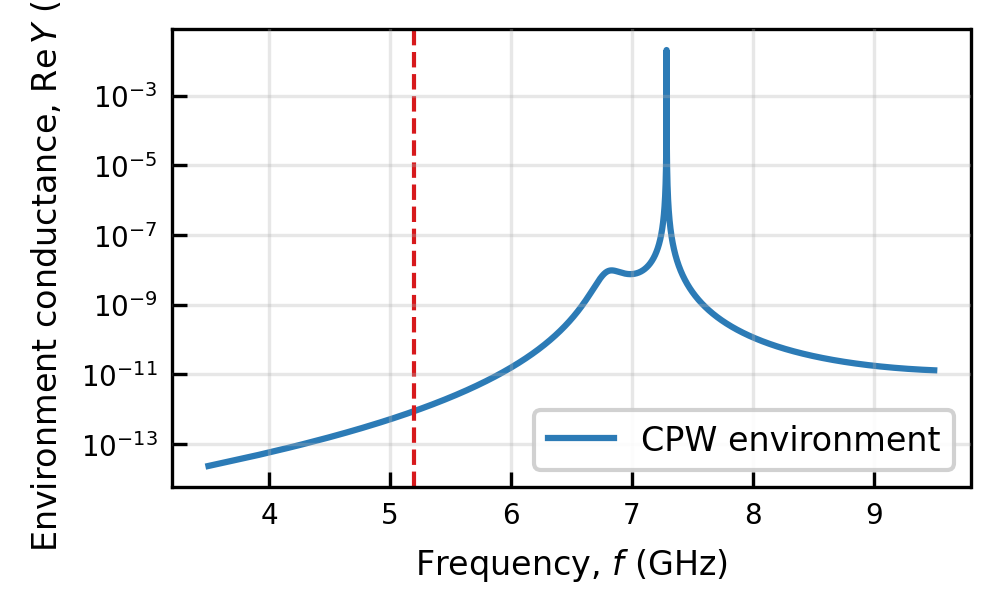

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='Frequency, $f$ (GHz)', ylabel='Environment conductance, $\\mathrm{Re}\\,Y$ (S)'>)

In [5]:
def input_admittance(net: rf.Network) -> np.ndarray:
    '''Admittance looking into port 1, far port terminated in its reference Z0.'''
    s11 = net.s[:, 0, 0]
    return Y0 * (1.0 - s11) / (1.0 + s11)


segments_env = [{"kind": "cpw", "d": d_r}, {"kind": "cpw", "d": d_f}]
Ccs_env = [Cc_qr, Cc_rf, Cc_out]
Ctogs_env = [Ctog] * 4

t0 = time.time()
freq_broad = rf.Frequency(3.5e9, 9.5e9, 10_001, unit="Hz")
env_cpw = resonator_chain_network_2port(
    freq_broad, segments_env, Ccs_env, Ctogs_env, cpw_params=cpw, Z0=Z0,
)
print(f"[{time.time()-t0:.1f} s] environment broad build")

ReY_cpw = input_admittance(env_cpw).real
f_GHz = freq_broad.f / 1e9

plot_curves(
    f_GHz,
    (ReY_cpw, "CPW environment"),
    yscale="log",
    xlabel=axis_label("Frequency", "f", "GHz"),
    ylabel=axis_label("Environment conductance", r"\mathrm{Re}\,Y", "S"),
    vline=f_q / 1e9,
)

The broad bump is the strongly loaded filter; the sharp line on top of it is
the readout mode. At the qubit frequency (vertical line) the conductance is
orders of magnitude down — that suppression *is* the Purcell protection.

## 3. Purcell $T_1$, with and without the filter

Comparing "filter" against "no filter" is only fair at the **same readout
linewidth** $\kappa_r$ — that is the number a designer must hold fixed (it
sets the measurement speed). So first measure $\kappa_r$ of the filtered
design as the FWHM of the readout peak in $\mathrm{Re}\,Y$, then calibrate the
coupler of a filterless readout (`Cc_direct`, readout tapped straight onto
the feedline) to reproduce it.

In [6]:
def peak_fwhm(f: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    '''(FWHM, f_peak) of the tallest peak in y(f), interpolated at half max.'''
    i = int(np.argmax(y))
    half = y[i] / 2.0
    above = y > half
    cross = np.where(np.diff(above.astype(int)))[0]
    left, right = cross[cross < i], cross[cross >= i]
    if len(left) == 0 or len(right) == 0:
        return float("nan"), float(f[i])
    def _x(j):
        return f[j] + (half - y[j]) * (f[j + 1] - f[j]) / (y[j + 1] - y[j])
    return float(_x(right[0]) - _x(left[-1])), float(f[i])


def env_chain(freqgrid, segments, Ccs, Ctogs):
    return resonator_chain_network_2port(
        freqgrid, segments, Ccs, Ctogs, cpw_params=cpw, Z0=Z0,
    )


t0 = time.time()

# kappa_r of the filtered design: dense window around the readout line
f_r_coarse = freq_broad.f[np.argmax(ReY_cpw)]
win_r = rf.Frequency(f_r_coarse - 25e6, f_r_coarse + 25e6, 4_001, unit="Hz")
kappa_r, f_r = peak_fwhm(
    win_r.f, input_admittance(env_chain(win_r, segments_env, Ccs_env, Ctogs_env)).real
)
print(f"filtered readout:  f_r = {f_r/1e9:.4f} GHz, kappa_r = {kappa_r/1e6:.3f} MHz")


# filterless reference: readout tapped straight onto the feedline
def kappa_direct(Cc_direct: float) -> tuple[float, float]:
    coarse = rf.Frequency(6.8e9, 7.8e9, 2_001, unit="Hz")
    segs, ccs, ctogs = [{"kind": "cpw", "d": d_r}], [Cc_qr, Cc_direct], [Ctog] * 2
    y = input_admittance(env_chain(coarse, segs, ccs, ctogs)).real
    fp = coarse.f[np.argmax(y)]
    win = rf.Frequency(fp - 30e6, fp + 30e6, 4_001, unit="Hz")
    return peak_fwhm(win.f, input_admittance(env_chain(win, segs, ccs, ctogs)).real)


cc_scan = np.geomspace(3e-15, 15e-15, 4)
kappa_scan = np.array([kappa_direct(cc)[0] for cc in cc_scan])
Cc_direct = invert_monotonic(cc_scan, kappa_scan, kappa_r, log=True)
kappa_chk, f_r_direct = kappa_direct(Cc_direct)
print(f"matched no-filter: Cc_direct = {Cc_direct*1e15:.2f} fF "
      f"-> kappa_r = {kappa_chk/1e6:.3f} MHz at {f_r_direct/1e9:.4f} GHz")
print(f"[{time.time()-t0:.1f} s] kappa extraction + matching")

filtered readout:  f_r = 7.2871 GHz, kappa_r = 0.098 MHz


matched no-filter: Cc_direct = 3.00 fF -> kappa_r = 0.203 MHz at 7.2820 GHz
[18.6 s] kappa extraction + matching


Now the comparison. Both environments are evaluated on the same broad grid;
one array division turns $\mathrm{Re}\,Y(\omega)$ into the full
$T_1(\omega)$ curve — sweeping the qubit frequency is *free*, no per-point
rebuild. The dotted line is the (filter-independent) decay through the
0.05 fF drive tap, $T_1^\mathrm{drive} = C_q / \big[(\omega C_d)^2 Z_0\big]$
— a reminder that once the filter is doing its job, some *other* channel
usually becomes the real limit.

[0.2 s] filterless broad build


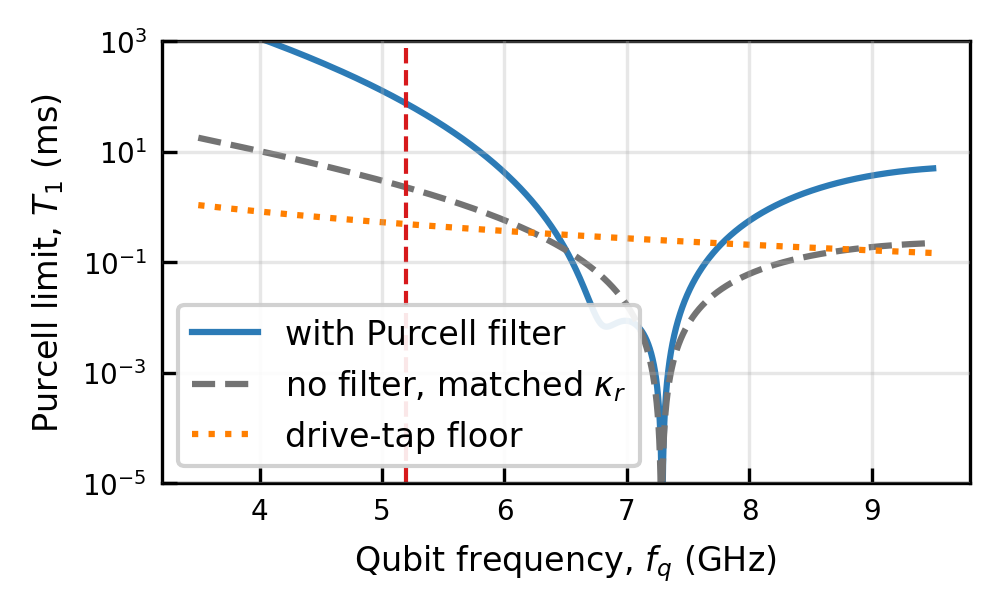

at f_q = 5.20 GHz:
  T1 (no filter, matched kappa_r) =     2251.5 us
  T1 (with Purcell filter)        =    73906.8 us
  protection factor               =       32.8x


In [7]:
t0 = time.time()
env_direct = env_chain(
    freq_broad, [{"kind": "cpw", "d": d_r}], [Cc_qr, Cc_direct], [Ctog] * 2,
)
print(f"[{time.time()-t0:.1f} s] filterless broad build")

T1_filt = C_q / np.maximum(ReY_cpw, 1e-300)
T1_direct = C_q / np.maximum(input_admittance(env_direct).real, 1e-300)
T1_drive = C_q / ((freq_broad.w * C_d) ** 2 * Z0)

plot_curves(
    f_GHz,
    (T1_filt * 1e3, "with Purcell filter"),
    (T1_direct * 1e3, "no filter, matched $\\kappa_r$", {"ls": "--", "color": "0.45"}),
    (T1_drive * 1e3, "drive-tap floor", {"ls": ":", "color": COLOR_SECONDARY}),
    yscale="log",
    xlabel=axis_label("Qubit frequency", "f_q", "GHz"),
    ylabel=axis_label("Purcell limit", "T_1", "ms"),
    vline=f_q / 1e9,
    ylim=(1e-5, 1e3),
)

i_q = int(np.argmin(np.abs(freq_broad.f - f_q)))
print(f"at f_q = {f_q/1e9:.2f} GHz:")
print(f"  T1 (no filter, matched kappa_r) = {T1_direct[i_q]*1e6:10.1f} us")
print(f"  T1 (with Purcell filter)        = {T1_filt[i_q]*1e6:10.1f} us")
print(f"  protection factor               = {T1_filt[i_q]/T1_direct[i_q]:10.1f}x")

## 4. The same design through the LOM pipeline

Everything above used the distributed CPW ground truth. Now do what this
package is for: reduce each CPW to an effective $(L, C)$ with the Optimized
fit — each fitted in its own subgroup with its **actual, asymmetric**
couplers (`Cc1`/`Cc2`) — and rebuild the environment as a pure lumped chain.
As in Tutorial 3, the Optimized model folds the ground caps into its
effective $(L, C)$, so the lumped chain drops the `Ctogs`.

[52.8 s] two OptimizedFit fits
readout LOM: L = 0.6450 nH, C = 733.61 fF
filter  LOM: L = 0.6535 nH, C = 724.03 fF


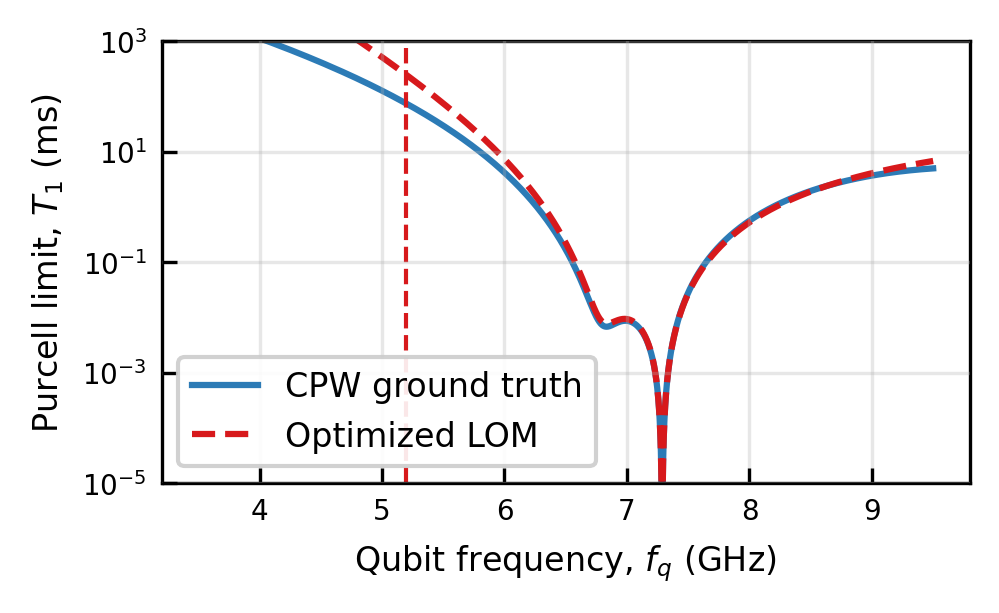

  T1 error of LOM at 4.6 GHz: +539.0 %
  T1 error of LOM at 5.2 GHz: +231.1 %
  T1 error of LOM at 6.2 GHz:  +54.4 %


In [8]:
t0 = time.time()
L_r, C_r = fit_lom(
    d_r, model="optimized", Cc1=Cc_qr, Cc2=Cc_rf, Ctog1=Ctog, Ctog2=Ctog,
    cpw_params=cpw,
)
L_f, C_f = fit_lom(
    d_f, model="optimized", Cc1=Cc_rf, Cc2=Cc_out, Ctog1=Ctog, Ctog2=Ctog,
    cpw_params=cpw,
)
print(f"[{time.time()-t0:.1f} s] two OptimizedFit fits")
print(f"readout LOM: L = {L_r*1e9:.4f} nH, C = {C_r*1e15:.2f} fF")
print(f"filter  LOM: L = {L_f*1e9:.4f} nH, C = {C_f*1e15:.2f} fF")

segments_env_lc = [
    {"kind": "lc", "L": L_r, "C": C_r},
    {"kind": "lc", "L": L_f, "C": C_f},
]
env_lom = resonator_chain_network_2port(
    freq_broad, segments_env_lc, Ccs_env, Ctogs=None, cpw_params=cpw, Z0=Z0,
)
T1_lom = C_q / np.maximum(input_admittance(env_lom).real, 1e-300)

plot_curves(
    f_GHz,
    (T1_filt * 1e3, "CPW ground truth", {"color": MODEL_COLORS["cpw"]}),
    (T1_lom * 1e3, "Optimized LOM", {"color": MODEL_COLORS["optimized"], "ls": "--"}),
    yscale="log",
    xlabel=axis_label("Qubit frequency", "f_q", "GHz"),
    ylabel=axis_label("Purcell limit", "T_1", "ms"),
    vline=f_q / 1e9,
    ylim=(1e-5, 1e3),
)

for f_probe in (4.6e9, f_q, 6.2e9):
    i = int(np.argmin(np.abs(freq_broad.f - f_probe)))
    err = 100.0 * (T1_lom[i] - T1_filt[i]) / T1_filt[i]
    print(f"  T1 error of LOM at {f_probe/1e9:.1f} GHz: {err:+6.1f} %")

The lumped environment reproduces the readout/filter structure and the
protection window around the readout frequency. Away from resonance the
residual error is the **single-mode truncation**: a fitted LC tank matches the
CPW line near its fundamental, but a real $\lambda/2$ line's off-resonant
impedance contains all its other modes. That error is inherited by *any*
single-mode Purcell estimate, not just this package's.

## 5. Design sweep: the filter–feedline coupler

Finally, the demo's design knob: $C_{c,\mathrm{out}}$ sets the filter
linewidth $\kappa_f$, and through $\kappa_r \simeq 4J^2/\kappa_f$ it drags
the readout linewidth and the qubit protection with it. Sweep it and read off
the trade the filter actually offers.

[98.8 s] design sweep, 5 points
 Cc_out (fF)  f_r (GHz)  kappa_r (MHz)  T1(f_q) (ms)
      60.000      7.287          0.104       332.075
      95.000      7.287          0.099       123.408
     130.000      7.287          0.097        61.866
     165.000      7.287          0.097        36.393
     200.000      7.287          0.095        23.739


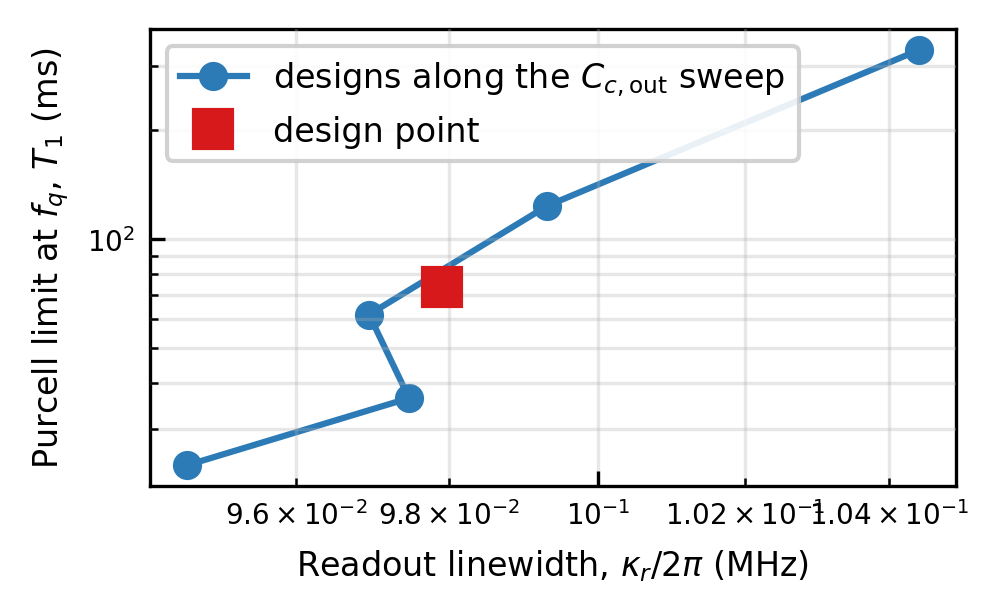

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='Readout linewidth, $\\kappa_r/2\\pi$ (MHz)', ylabel='Purcell limit at $f_q$, $T_1$ (ms)'>)

In [9]:
t0 = time.time()
cc_outs = np.linspace(60e-15, 200e-15, 5)
rows = []
for cc in cc_outs:
    ccs_i = [Cc_qr, Cc_rf, cc]
    coarse = rf.Frequency(6.9e9, 7.7e9, 2_001, unit="Hz")
    y = input_admittance(env_chain(coarse, segments_env, ccs_i, Ctogs_env)).real
    fp = coarse.f[np.argmax(y)]
    win = rf.Frequency(fp - 30e6, fp + 30e6, 4_001, unit="Hz")
    k_i, f_i = peak_fwhm(
        win.f, input_admittance(env_chain(win, segments_env, ccs_i, Ctogs_env)).real
    )
    fq_win = rf.Frequency(f_q - 20e6, f_q + 20e6, 801, unit="Hz")
    y_q = input_admittance(env_chain(fq_win, segments_env, ccs_i, Ctogs_env)).real
    T1_q = C_q / y_q[len(y_q) // 2]
    rows.append({
        "Cc_out (fF)": cc * 1e15,
        "f_r (GHz)": f_i / 1e9,
        "kappa_r (MHz)": k_i / 1e6,
        "T1(f_q) (ms)": T1_q * 1e3,
    })
print(f"[{time.time()-t0:.1f} s] design sweep, {len(cc_outs)} points")

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

plot_curves(
    sweep_df["kappa_r (MHz)"],
    (sweep_df["T1(f_q) (ms)"], "designs along the $C_{c,\\mathrm{out}}$ sweep"),
    fmt="o-",
    xscale="log", yscale="log",
    xlabel=axis_label("Readout linewidth", r"\kappa_r/2\pi", "MHz"),
    ylabel=axis_label("Purcell limit at $f_q$", "T_1", "ms"),
    point=(kappa_r / 1e6, T1_filt[i_q] * 1e3),
)

Each marker is a buildable device: pick the $\kappa_r$ your measurement speed
needs, read off the Purcell limit the filter leaves you (the highlighted point
is the design used throughout this demo). A faster readout costs protection,
but the whole trajectory sits far above the filterless number from section 3.

---

**Where to go from here.** Swap the readout for a hanger tapped off the
feedline (Tutorials 8–9), refit at a different substrate or geometry by
changing `CPWParams`, or compare against a full simulation as in Tutorial 5.
The two inline helpers here (`input_admittance`, `peak_fwhm`) are candidates
to graduate into `simpleLOMs.readout` if you find yourself importing them
from a demo.